# Ejercicio 7 - Image augmentation

Este notebook cubre el Ejercicio 7: definir transformaciones de image augmentation para el dataset ASL Alphabet, justificarlas, visualizarlas, y discutir las dos preguntas del enunciado.

1. ¿Por qué un flip horizontal podría cambiar el significado de una seña en vez de solo aumentar los datos?
2. ¿Qué transformaciones sí tienen sentido para señas y cuáles no?

Este notebook define y visualiza el pipeline de augmentation, pero no reentrena los modelos de los Ejercicios 4 a 6. Cada modelo se reentrena en su propio notebook (cnn_simple.ipynb, cnn_profunda.ipynb, redesNeuronalesSimple.ipynb, randomForest.ipynb), importando el pipeline definido en augmentation.py para no duplicar código entre integrantes del grupo.

Tampoco depende de archivos generados previamente en una máquina en particular, como el .npz de preprocesamiento.ipynb. Si no encuentra el dataset localmente lo descarga con kagglehub, igual que preprocesamiento.ipynb, así que puede correr desde una copia limpia del repositorio en cualquier máquina.

In [1]:
# Dependencias. Se puede correr sin problema aunque ya estén instaladas (pip no reinstala
# si la versión ya está satisfecha) — pensado para que el notebook funcione en una máquina nueva.
%pip install -q numpy pandas pillow matplotlib scikit-learn tensorflow kagglehub


[notice] A new release of pip is available: 25.3 -> 26.2.1
[notice] To update, run: pip install --upgrade pip


Note: you may need to restart the kernel to use updated packages.


In [2]:
from pathlib import Path
import random

import numpy as np
import matplotlib.pyplot as plt

RANDOM_SEED = 42
IMG_SIZE = 64  # misma resolución usada en preprocesamiento.ipynb

random.seed(RANDOM_SEED)
np.random.seed(RANDOM_SEED)

## 1. Obtención de datos (portable)

Igual que en preprocesamiento.ipynb: si ya existe una copia plana del dataset junto al notebook (asl_alphabet_train/) se usa directamente, si no, se descarga con kagglehub. Para este notebook no necesitamos las cerca de 87,000 imágenes ni la submuestra completa de 600 por clase usada para entrenar, solo unas pocas imágenes por letra para visualizar el efecto de cada transformación, así que la carga es liviana y rápida en cualquier máquina.

In [3]:
FLAT_TRAIN_DIR = Path("asl_alphabet_train")
LOCAL_FALLBACK = Path("asl-alphabet/versions/1")

if FLAT_TRAIN_DIR.exists():
    TRAIN_DIR = FLAT_TRAIN_DIR
else:
    try:
        import kagglehub
        DATASET_PATH = Path(kagglehub.dataset_download("grassknoted/asl-alphabet"))
    except Exception as e:
        print(f"kagglehub no disponible ({e}); usando copia local en {LOCAL_FALLBACK}")
        DATASET_PATH = LOCAL_FALLBACK
    TRAIN_DIR = DATASET_PATH / "asl_alphabet_train" / "asl_alphabet_train"

assert TRAIN_DIR.exists(), f"No se encontró el directorio de entrenamiento en {TRAIN_DIR}"
print("Directorio de entrenamiento:", TRAIN_DIR)

Directorio de entrenamiento: asl_alphabet_train


In [4]:
from PIL import Image

# Letras de muestra: un par "normales" (A, E) más los dos grupos que el EDA identificó como
# visualmente confusos (M/N/S y U/V/R/W/X), para poder ilustrar el efecto de las transformaciones
# justo sobre las letras donde más importa no introducir ruido.
DEMO_LETTERS = ["A", "E", "M", "N", "S", "U", "V", "R", "W", "X"]
N_PER_LETTER = 3


def load_img(path, size=IMG_SIZE):
    img = Image.open(path).convert("RGB").resize((size, size), Image.BILINEAR)
    return np.asarray(img, dtype=np.float32) / 255.0


samples = {}
for letter in DEMO_LETTERS:
    files = sorted((TRAIN_DIR / letter).glob("*.jpg"))
    chosen = random.sample(files, min(N_PER_LETTER, len(files)))
    samples[letter] = np.stack([load_img(p) for p in chosen])

print({k: v.shape for k, v in samples.items()})

{'A': (3, 64, 64, 3), 'E': (3, 64, 64, 3), 'M': (3, 64, 64, 3), 'N': (3, 64, 64, 3), 'S': (3, 64, 64, 3), 'U': (3, 64, 64, 3), 'V': (3, 64, 64, 3), 'R': (3, 64, 64, 3), 'W': (3, 64, 64, 3), 'X': (3, 64, 64, 3)}


## 2. Transformaciones que sí tienen sentido para señas ASL

El pipeline vive en augmentation.py para que cualquier notebook de modelo lo importe con from augmentation import get_augmentation_pipeline. Se eligieron transformaciones que simulan cómo una persona real presenta la mano frente a una cámara, sin tocar la identidad de la seña:

| Transformación | Rango | Por qué tiene sentido |
|---|---|---|
| Rotación | ±15° | La muñeca rara vez está perfectamente vertical frente a la cámara. |
| Traslación (shift) | ±10% ancho/alto | La mano no siempre está centrada en el encuadre. |
| Zoom | ±15% | La distancia mano-cámara varía entre tomas y entre usuarios. |
| Brillo | ±20% | La iluminación del cuarto o celular varía, justo lo que pasaría con la app real. |
| Contraste | ±20% | Igual que brillo, cámaras y condiciones de luz distintas producen distinto contraste. |

Todas son transformaciones geométricas o fotométricas leves que no alteran qué dedos están extendidos, cruzados o doblados, que es lo que efectivamente define la letra.

In [5]:
from augmentation import get_augmentation_pipeline

data_augmentation = get_augmentation_pipeline()
data_augmentation.summary()

Model: "asl_data_augmentation"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ random_rotation                 │ ?                      │   0 (unbuilt) │
│ (RandomRotation)                │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ random_translation              │ ?                      │   0 (unbuilt) │
│ (RandomTranslation)             │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ random_zoom (RandomZoom)        │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ random_brightness               │ ?                      │   0 (unbuilt) │
│ (RandomBrightness)              │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ random_contrast                 │ ?                      │   0 (unbuilt) │
│ (RandomContrast)                │                        │               │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 0 (0.00 B)

 Trainable params: 0 (0.00 B)

 Non-trainable params: 0 (0.00 B)

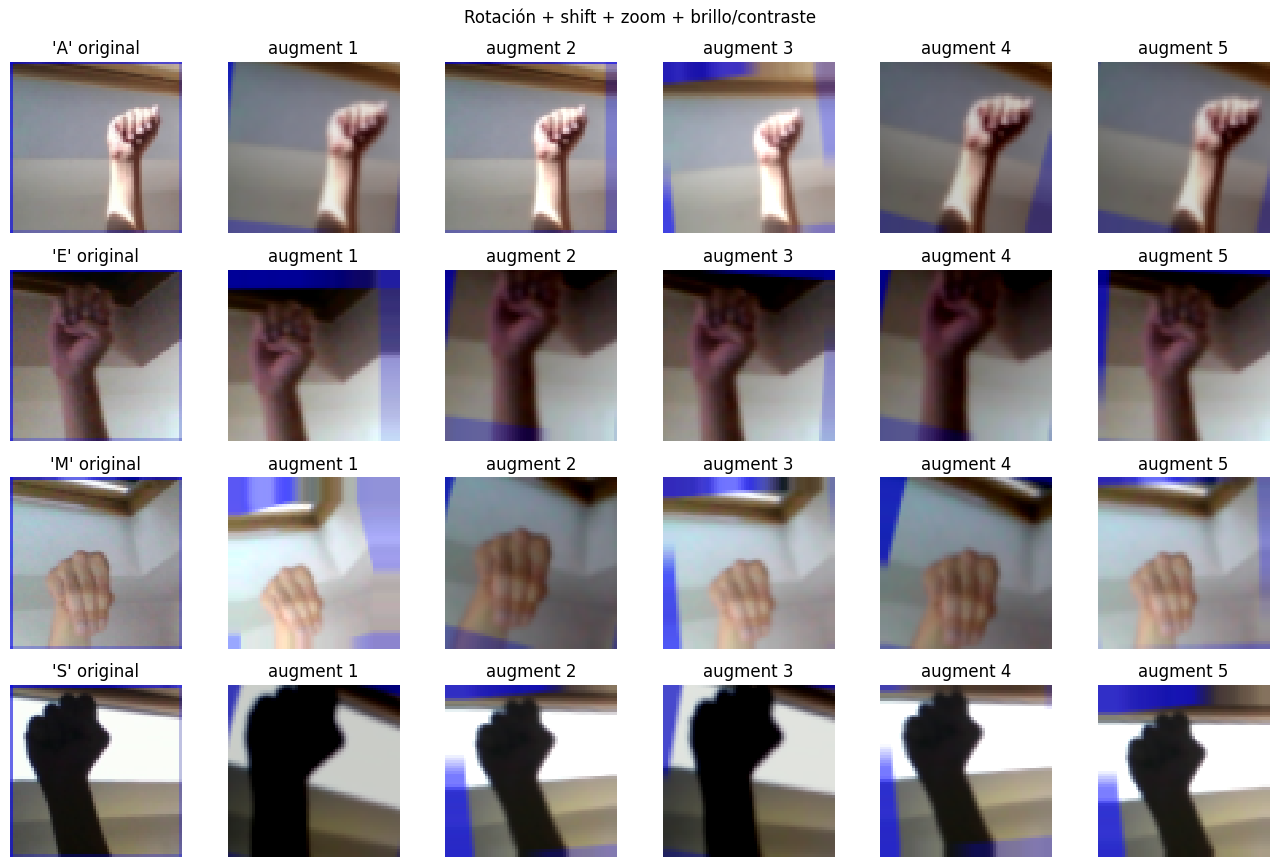

In [6]:
def plot_augmentation_grid(letters, n_versions=5, title=""):
    fig, axes = plt.subplots(
        len(letters), n_versions + 1, figsize=(2.2 * (n_versions + 1), 2.2 * len(letters))
    )
    if len(letters) == 1:
        axes = axes[None, :]
    for i, letter in enumerate(letters):
        base = samples[letter][0]
        axes[i, 0].imshow(base, interpolation="nearest")
        axes[i, 0].set_title(f"'{letter}' original")
        axes[i, 0].axis("off")

        batch = np.repeat(base[None, ...], n_versions, axis=0)
        augmented = data_augmentation(batch, training=True).numpy()
        for j in range(n_versions):
            axes[i, j + 1].imshow(np.clip(augmented[j], 0, 1), interpolation="nearest")
            axes[i, j + 1].set_title(f"augment {j + 1}")
            axes[i, j + 1].axis("off")
    fig.suptitle(title)
    plt.tight_layout()
    plt.show()


plot_augmentation_grid(["A", "E", "M", "S"], title="Rotación + shift + zoom + brillo/contraste")

Las 5 versiones aumentadas de cada letra siguen siendo, sin ambigüedad, la misma seña: cambia el encuadre, el ángulo y la iluminación, pero la forma de la mano (qué dedos están extendidos, cruzados o doblados) se mantiene intacta.

## 3. Por qué no usamos flip horizontal (ni vertical)

Probamos qué pasa si agregamos un RandomFlip("horizontal") al pipeline, aplicado sobre el grupo de letras que el EDA (eda.ipynb) ya había identificado como visualmente confuso entre sí: U, V, R, W, X. Todas se arman con combinaciones parecidas de dedos índice y medio extendidos o cruzados, y se diferencian por detalles finos de orientación.

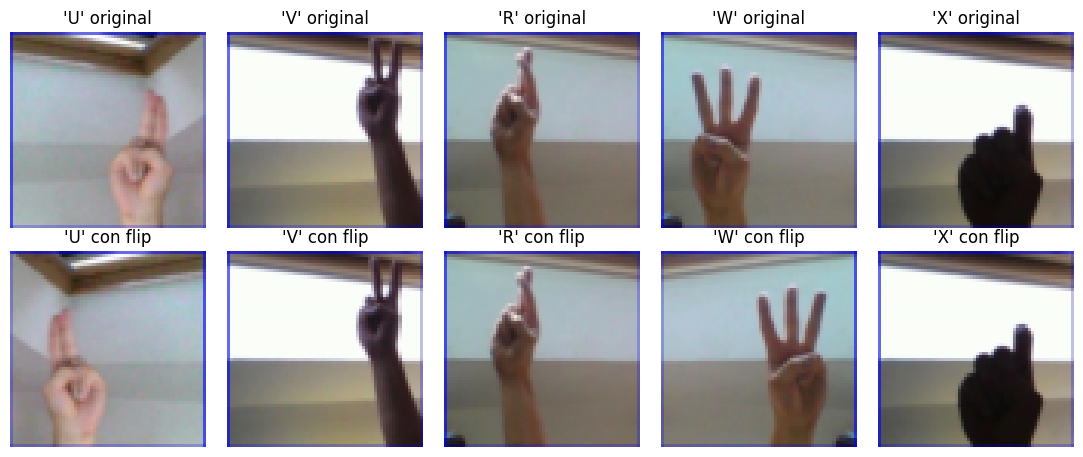

In [7]:
from tensorflow import keras
from tensorflow.keras import layers

flip_demo = keras.Sequential([layers.RandomFlip("horizontal", seed=RANDOM_SEED)])

confusable_letters = ["U", "V", "R", "W", "X"]
fig, axes = plt.subplots(2, len(confusable_letters), figsize=(2.2 * len(confusable_letters), 4.6))
for j, letter in enumerate(confusable_letters):
    base = samples[letter][0]
    flipped = flip_demo(base[None, ...], training=True).numpy()[0]

    axes[0, j].imshow(base, interpolation="nearest")
    axes[0, j].set_title(f"'{letter}' original")
    axes[0, j].axis("off")

    axes[1, j].imshow(np.clip(flipped, 0, 1), interpolation="nearest")
    axes[1, j].set_title(f"'{letter}' con flip")
    axes[1, j].axis("off")

plt.tight_layout()
plt.show()

Lo que se observa: al espejar horizontalmente, la dirección en la que cruzan o se inclinan los dedos se invierte. Para letras simples como una mano abierta esto no cambia nada porque la seña es simétrica. Pero para el grupo U/V/R/W/X, la letra se distingue precisamente por hacia dónde se cruzan o inclinan los dedos índice y medio, así que invertir esa dirección puede producir una imagen cuya forma de mano se parece más a la de otra letra del mismo grupo que a la letra original.

### Respuesta a la pregunta del enunciado

¿Por qué un flip horizontal podría cambiar el significado de una seña en vez de solo aumentar los
datos? Porque el flip horizontal no es una variación neutra de cómo se ve la misma seña, es una transformación geométrica que invierte relaciones espaciales (qué dedo está delante de cuál, hacia qué lado se inclina la mano) que son justamente la señal que distingue una letra de otra. A diferencia de rotar, trasladar o hacer zoom, que preservan esas relaciones, espejar horizontalmente puede convertir una imagen de la letra X en una imagen que para el modelo es indistinguible de la letra R o V. El resultado no es más ejemplos de la clase X sino ejemplos mal etiquetados, que le enseñan al modelo una relación falsa entre esa forma de mano y la clase X, degradando justo la distinción entre las letras que el EDA (eda.ipynb) ya había marcado como las más confusas (M/N/S y U/V/R/W/X). Además, ninguna imagen de flip vertical corresponde a cómo una cámara vería una mano en este producto, el usuario nunca firma boca abajo, así que tampoco aporta variabilidad realista.

¿Qué transformaciones sí tienen sentido y cuáles no?

| Sí tiene sentido | Por qué | No tiene sentido | Por qué |
|---|---|---|---|
| Rotación leve (±15°) | Variación natural del ángulo de muñeca | Flip horizontal | Invierte relaciones dedo a dedo que definen la letra, puede volver una clase indistinguible de otra |
| Traslación (shift) | La mano no siempre está centrada | Flip vertical | Nunca ocurre en el uso real de la app, la mano no aparece invertida |
| Zoom leve (±15%) | Distancia variable a la cámara | Rotaciones grandes (más de 45°) | Una muñeca no gira tanto frente a una cámara fija, generaría poses irreales |
| Brillo y contraste | Iluminación de cuarto o cámara varía | Distorsión de color o inversión de canales | Rompe la señal de tono de piel, relevante para la reflexión de accesibilidad del Ejercicio 9, sin corresponder a ninguna condición real |